# Anime Data Analysis: A Fan's Perspective

## 1. Introduzione e Definizione dei Task
Questo notebook è stato progettato seguendo i principi dello **User-Centered Design (UCD)**. La nostra *User Persona* di riferimento è il **Fan** dell'animazione giapponese. 

A differenza di un analista di mercato, il Fan esplora i dati spinto da curiosità e passione. I task principali che questa analisi intende supportare sono:
1. Comprendere il rapporto tra popolarità (engagement della community) e qualità percepita (rating).
2. Esplorare le preferenze e i trend all'interno del database.

Seguendo il **Mantra di Shneiderman** (*"Overview first, zoom and filter, then details-on-demand"*), il processo inizierà con un'analisi esplorativa (EDA) per valutare la "salute" dei dati, per poi procedere con visualizzazioni mirate.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione estetica (Principio HCI: Leggibilità e contrasto)
sns.set_theme(style="whitegrid")

# 1. Caricamento dei dataset dalla cartella dedicata
print("Caricamento dati in corso...")
df_details = pd.read_csv('datasets/details.csv', low_memory=False)
df_stats = pd.read_csv('datasets/stats.csv', low_memory=False)
df_favs = pd.read_csv('datasets/favs.csv', low_memory=False)
print("Caricamento completato!\n")

# 2. Esplorazione Strutturale (Mantra di Shneiderman: Overview first)
def profile_dataframe(df, name):
    print(f"--- Profilazione Dataset: {name} ---")
    print(f"Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne")
    null_counts = df.isnull().sum()
    print("Valori Nulli (Top 5):")
    print(null_counts[null_counts > 0].sort_values(ascending=False).head(5))
    print("-" * 40 + "\n")

profile_dataframe(df_details, "Details")
profile_dataframe(df_stats, "Stats")
profile_dataframe(df_favs, "Favs")

# 3. Analisi di Sanità dei Dati (Controllo Outliers) - VERSIONE ULTRA-OTTIMIZZATA

# OPTIMIZATION: Evitiamo merge non necessari. Le colonne 'title' e 'scored_by' 
# sono già in df_details. Gestiamo i valori Nulli riempiendoli con 0, 
# poiché rappresentano anime senza alcun voto.
df_details['scored_by'] = df_details['scored_by'].fillna(0)

# Mostriamo i Top 5 anime per numero di voti per individuare i "giganti" (Outliers)
print("--- Top 5 Anime per numero di voti (Sanity Check Ottimizzato) ---")
top_5_anime = df_details[['title', 'scored_by']].sort_values(by='scored_by', ascending=False).head(5)
print(top_5_anime)

Caricamento dati in corso...
Caricamento completato!

--- Profilazione Dataset: Details ---
Dimensioni: 28955 righe, 29 colonne
Valori Nulli (Top 5):
year         22689
season       22689
end_date     17688
scored_by    10073
score        10073
dtype: int64
----------------------------------------

--- Profilazione Dataset: Stats ---
Dimensioni: 28955 righe, 27 colonne
Valori Nulli (Top 5):
score_1_votes         430
score_1_percentage    430
score_2_votes         430
score_2_percentage    430
score_3_votes         430
dtype: int64
----------------------------------------

--- Profilazione Dataset: Favs ---
Dimensioni: 4178747 righe, 3 colonne
Valori Nulli (Top 5):
username    4
dtype: int64
----------------------------------------

--- Top 5 Anime per numero di voti (Sanity Check Ottimizzato) ---
                                  title  scored_by
22010                Shingeki no Kyojin  2979733.0
4788                         Death Note  2919353.0
17990                     One Punch Man

## 2. Exploratory Data Analysis (EDA) e Giustificazione delle Scelte di Design

L'analisi strutturale iniziale sui dataset `details`, `stats` e `favs` ha rivelato importanti asimmetrie nel dominio dei dati, che richiedono specifiche strategie di *Data Cleaning* e *Visualisation* per evitare di presentare informazioni fuorvianti:

* **Gestione dei Missing Data (Bias Prevention):** Su quasi 29.000 titoli, oltre 22.000 mancano dei campi `year` e `season`. Rimuovere queste righe (*Listwise Deletion*) introdurrebbe un grave **Selection Bias**. Questi valori nulli rappresentano una "realtà" del dominio (OVA, Film, Speciali musicali che non seguono le canoniche stagioni televisive). Verranno filtrati solo in caso di analisi strettamente cronologiche.
* **Presenza di Outlier ("Giganti"):** La distribuzione dei voti è fortemente sbilanciata. Titoli come *Death Note* o *One Punch Man* superano i 2 milioni di voti, mentre la maggioranza degli anime ha volumi di interazione ordini di grandezza inferiori.
* **Scelta Architetturale (Log Scale):** Come definito dai principi di *Large Scale Data Visualisation*, mappare questi dati su un grafico lineare genererebbe una rappresentazione "Bad", schiacciando il 99% dei titoli a causa degli outlier. Per la prossima visualizzazione, applicheremo una **Scala Logaritmica** sull'asse delle ascisse per garantire leggibilità e preservare le proporzioni su tutta la scala dei dati.

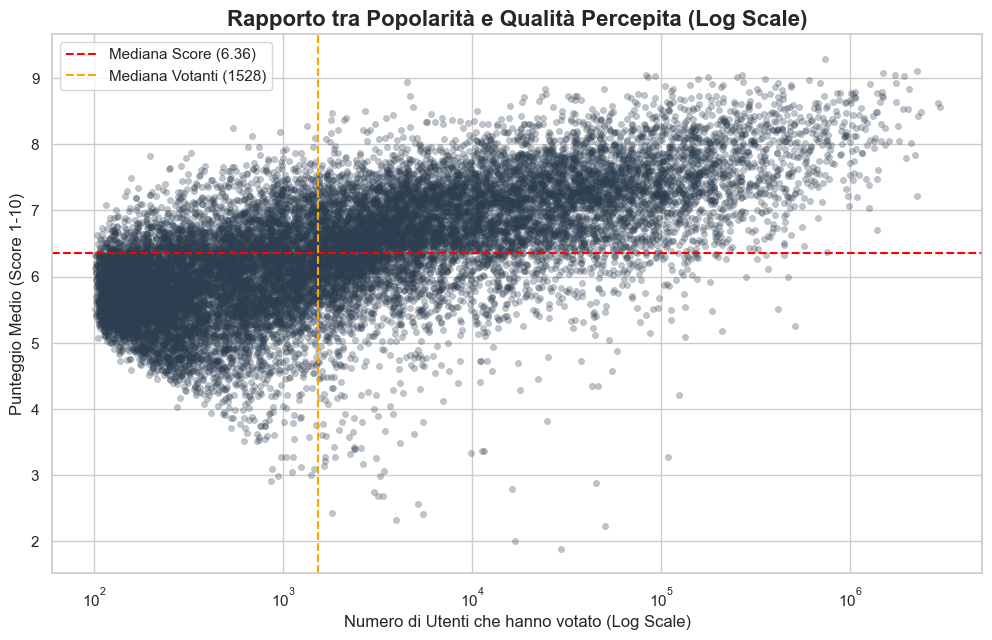

In [4]:
# Creiamo una figura adeguata (HCI: dimensioni ampie per evitare sovraffollamento visivo)
plt.figure(figsize=(12, 7))

# Rimuoviamo gli anime che non hanno ricevuto voti o punteggi per evitare errori nel logaritmo
df_valid_scores = df_details[(df_details['score'].notnull()) & (df_details['scored_by'] > 0)]

# Scatter plot: Popolarità vs Voto Medio
# Usiamo l'attributo 'alpha' per gestire l'overplotting (sovrapposizione dei punti)
sns.scatterplot(
    data=df_valid_scores, 
    x='scored_by', 
    y='score', 
    alpha=0.3, # Trasparenza per vedere la densità dei punti
    color='#2C3E50',
    edgecolor=None,
    s=20 # Dimensione dei punti
)

# APPLICHIAMO LA SCALA LOGARITMICA PROMESSA NEL MARKDOWN
plt.xscale('log')

# Titoli e label chiari (HCI: Riduciamo il carico cognitivo spiegando gli assi)
plt.title('Rapporto tra Popolarità e Qualità Percepita (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Numero di Utenti che hanno votato (Log Scale)', fontsize=12)
plt.ylabel('Punteggio Medio (Score 1-10)', fontsize=12)

# Aggiungiamo due linee per indicare le mediane e orientare l'utente
mediana_score = df_valid_scores['score'].median()
mediana_popolarita = df_valid_scores['scored_by'].median()

plt.axhline(mediana_score, color='red', linestyle='--', linewidth=1.5, label=f'Mediana Score ({mediana_score})')
plt.axvline(mediana_popolarita, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana Votanti ({mediana_popolarita:.0f})')

plt.legend()
plt.show()